# MLP With Crop and Configurable Split Methods

This notebook trains **one crop-aware MLP** to predict `Mean_Yield`.

It supports the same split choices used in `yield_models_comparison_train_val_test_cv.ipynb`:

- `random`
- `last_years`
- `random_years`
- `group_kfold_year`

## Model inputs

- all numeric features
- one-hot encoded `Crop`
- `Municipality` is excluded

## Split behavior

- For `random`, `last_years`, and `random_years`:
  - train on `train`
  - early stop on `validation`
  - report metrics on `train`, `validation`, and `test`
- For `group_kfold_year`:
  - reserve the last `n_test_years` as the final outer `test` set
  - run inner `GroupKFold` by `Year` on the remaining years
  - report fold validation metrics and their mean
  - fit one final model on all train+validation rows using the median best epoch from the inner folds
  - report final metrics on the outer `test` set


In [40]:
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [41]:
# =========================
# Global configuration
# =========================
RANDOM_STATE = 42

SPLIT_METHOD = "group_kfold_year"   # "random", "last_years", "random_years", "group_kfold_year"

TEST_SIZE = 0.1875
VAL_SIZE = 0.1875
N_TRAIN_YEARS = 10
N_VAL_YEARS = 3
N_TEST_YEARS = 3
N_SPLITS = 3

BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 250
PATIENCE = 25
MIN_DELTA = 1e-5
HIDDEN_DIM = 64
N_HIDDEN_LAYERS = 2

USE_GPU_IF_AVAILABLE = True

TARGET_COL = "Mean_Yield"
CROP_COL = "Crop"
DATA_PATH = Path("./prepared/yields_weather_by_crop.csv")


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(RANDOM_STATE)
DEVICE = torch.device("cuda" if (USE_GPU_IF_AVAILABLE and torch.cuda.is_available()) else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [42]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Shape: (4864, 78)


,Year,Municipality,Crop,Mean_Yield,05_Q1_CDD,05_Q2_CDD,06_Q1_CDD,06_Q2_CDD,07_Q1_CDD,07_Q2_CDD,...,07_Q1_Ptol,07_Q2_Ptol,08_Q1_Ptol,08_Q2_Ptol,09_Q1_Ptol,09_Q2_Ptol,10_Q1_Ptol,10_Q2_Ptol,Latitude,Longitude
0,1996,ALEXANDER,ARGENTINE CANOLA,0.728428,0.0,1.406025,32.701730,41.166500,31.423716,15.575997,...,0.080075,0.068031,0.044390,0.045396,0.053233,0.024934,0.015926,0.030042,50.6667,-96.5
1,1996,ALEXANDER,OATS,1.215000,0.0,1.406025,32.701730,41.166500,31.423716,15.575997,...,0.080075,0.068031,0.044390,0.045396,0.053233,0.024934,0.015926,0.030042,50.6667,-96.5
2,1996,ALONSA,ALFALFA/GRASS MIX.,1.609253,0.0,2.014729,37.197368,35.920028,39.128350,18.739317,...,0.058935,0.080042,0.030213,0.010850,0.033199,0.015887,0.017048,0.052276,NaN,NaN
3,1996,ARGYLE,ALFALFA,2.080575,0.0,0.152813,24.440870,34.404783,27.131971,17.745561,...,0.030000,0.070000,0.030000,0.030000,0.020000,0.020000,0.000000,0.020000,NaN,NaN
4,1996,ARGYLE,ALFALFA/GRASS MIX.,1.658000,0.0,0.152813,24.440870,34.404783,27.131971,17.745561,...,0.030000,0.070000,0.030000,0.030000,0.020000,0.020000,0.000000,0.020000,NaN,NaN


In [43]:
y = df[TARGET_COL].copy()

drop_cols = [TARGET_COL]
if "Municipality" in df.columns:
    drop_cols.append("Municipality")

X = df.drop(columns=drop_cols).copy()

cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype).startswith("category")]
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")
print("Categorical columns:", cat_cols)
print("Crop unique values:", X[CROP_COL].nunique())

Numeric columns: 75
Categorical columns: 1
Categorical columns: ['Crop']
Crop unique values: 16


In [44]:
def split_dataset(
    X,
    y,
    method="random",
    random_state=42,
    test_size=0.1875,
    val_size=0.1875,
    n_val_years=3,
    n_test_years=3,
    n_train_years=10,
    n_splits=3,
):
    """
    Split dataset using a train/validation/test logic.

    Methods
    -------
    - "random": random row split with proportions 0.625 / 0.1875 / 0.1875
    - "last_years": chronological split by years
    - "random_years": random split by years
    - "group_kfold_year":
        outer split = train+validation years vs final test years
        inner split = GroupKFold(year) on train+validation years
    """

    if method == "random":
        X_trainval, X_test, y_trainval, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
        val_relative_size = val_size / (1.0 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_trainval, y_trainval, test_size=val_relative_size, random_state=random_state
        )

        print("Random split")
        print("Train size:", X_train.shape, "Validation size:", X_val.shape, "Test size:", X_test.shape)

        return {
            "mode": "holdout",
            "X_train": X_train,
            "X_val": X_val,
            "X_test": X_test,
            "y_train": y_train,
            "y_val": y_val,
            "y_test": y_test,
        }

    elif method == "last_years":
        years = sorted(X["Year"].unique())
        if len(years) < n_val_years + n_test_years + 1:
            raise ValueError("Not enough distinct years for last_years split.")

        test_years = years[-n_test_years:]
        val_years = years[-(n_val_years + n_test_years):-n_test_years]
        train_years = years[:-(n_val_years + n_test_years)]

        print("Train years:", train_years)
        print("Validation years:", val_years)
        print("Test years:", test_years)

        train_mask = X["Year"].isin(train_years)
        val_mask = X["Year"].isin(val_years)
        test_mask = X["Year"].isin(test_years)

        return {
            "mode": "holdout",
            "X_train": X.loc[train_mask].copy(),
            "X_val": X.loc[val_mask].copy(),
            "X_test": X.loc[test_mask].copy(),
            "y_train": y.loc[train_mask].copy(),
            "y_val": y.loc[val_mask].copy(),
            "y_test": y.loc[test_mask].copy(),
            "train_years": train_years,
            "val_years": val_years,
            "test_years": test_years,
        }

    elif method == "random_years":
        rng = np.random.default_rng(random_state)
        years = np.array(sorted(X["Year"].unique()))

        if len(years) < n_train_years + n_val_years + n_test_years:
            raise ValueError("Not enough distinct years for random_years split.")

        chosen_years = rng.choice(years, size=n_train_years + n_val_years + n_test_years, replace=False)
        rng.shuffle(chosen_years)

        train_years = sorted(chosen_years[:n_train_years].tolist())
        val_years = sorted(chosen_years[n_train_years:n_train_years + n_val_years].tolist())
        test_years = sorted(chosen_years[n_train_years + n_val_years:].tolist())

        print("Train years:", train_years)
        print("Validation years:", val_years)
        print("Test years:", test_years)

        train_mask = X["Year"].isin(train_years)
        val_mask = X["Year"].isin(val_years)
        test_mask = X["Year"].isin(test_years)

        return {
            "mode": "holdout",
            "X_train": X.loc[train_mask].copy(),
            "X_val": X.loc[val_mask].copy(),
            "X_test": X.loc[test_mask].copy(),
            "y_train": y.loc[train_mask].copy(),
            "y_val": y.loc[val_mask].copy(),
            "y_test": y.loc[test_mask].copy(),
            "train_years": train_years,
            "val_years": val_years,
            "test_years": test_years,
        }

    elif method == "group_kfold_year":
        years = sorted(X["Year"].unique())
        if len(years) < n_test_years + n_splits:
            raise ValueError("Not enough distinct years for outer test split + GroupKFold.")

        test_years = years[-n_test_years:]
        trainval_years = years[:-n_test_years]

        trainval_mask = X["Year"].isin(trainval_years)
        test_mask = X["Year"].isin(test_years)

        X_trainval = X.loc[trainval_mask].copy()
        y_trainval = y.loc[trainval_mask].copy()
        X_test = X.loc[test_mask].copy()
        y_test = y.loc[test_mask].copy()

        groups = X_trainval["Year"].to_numpy()
        gkf = GroupKFold(n_splits=n_splits)
        cv_splits = list(gkf.split(X_trainval, y_trainval, groups=groups))

        print("Train+validation years:", trainval_years)
        print("Outer test years:", test_years)
        print("Train+validation size:", X_trainval.shape, "Test size:", X_test.shape)
        print("Inner GroupKFold n_splits:", n_splits)

        for fold_id, (_, val_idx) in enumerate(cv_splits, start=1):
            fold_val_years = sorted(X_trainval.iloc[val_idx]["Year"].unique())
            print(f"Fold {fold_id}: validation years = {fold_val_years}")

        return {
            "mode": "cv",
            "X_trainval": X_trainval,
            "X_test": X_test,
            "y_trainval": y_trainval,
            "y_test": y_test,
            "cv_splits": cv_splits,
            "trainval_years": trainval_years,
            "test_years": test_years,
        }

    else:
        raise ValueError(f"Unknown method: {method}")

In [45]:
split_output = split_dataset(
    X,
    y,
    method=SPLIT_METHOD,
    random_state=RANDOM_STATE,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    n_train_years=N_TRAIN_YEARS,
    n_val_years=N_VAL_YEARS,
    n_test_years=N_TEST_YEARS,
    n_splits=N_SPLITS,
)

Train+validation years: [np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008)]
Outer test years: [np.int64(2009), np.int64(2010), np.int64(2011)]
Train+validation size: (3952, 76) Test size: (912, 76)
Inner GroupKFold n_splits: 3
Fold 1: validation years = [np.int64(1996), np.int64(1999), np.int64(2002), np.int64(2005), np.int64(2008)]
Fold 2: validation years = [np.int64(1998), np.int64(2001), np.int64(2004), np.int64(2007)]
Fold 3: validation years = [np.int64(1997), np.int64(2000), np.int64(2003), np.int64(2006)]


In [46]:
def make_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                ]),
                numeric_features,
            ),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                categorical_features,
            ),
        ],
        remainder="drop",
    )


def transform_splits(preprocessor, X_train, X_val=None, X_test=None, fit_on="train"):
    if fit_on != "train":
        raise ValueError("fit_on must be 'train'")

    X_train_proc = preprocessor.fit_transform(X_train).astype(np.float32)
    X_val_proc = None if X_val is None else preprocessor.transform(X_val).astype(np.float32)
    X_test_proc = None if X_test is None else preprocessor.transform(X_test).astype(np.float32)
    return X_train_proc, X_val_proc, X_test_proc


def make_loader(X_arr, y_arr, batch_size, shuffle):
    dataset = TensorDataset(
        torch.tensor(X_arr, dtype=torch.float32),
        torch.tensor(y_arr.to_numpy(dtype=np.float32).reshape(-1, 1), dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [47]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 64, n_hidden_layers: int = 2):
        super().__init__()

        if n_hidden_layers not in [1, 2]:
            raise ValueError("n_hidden_layers must be 1 or 2.")

        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]

        if n_hidden_layers == 2:
            layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.ReLU()])

        layers.append(nn.Linear(hidden_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def run_train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    n_samples = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)

    return running_loss / n_samples


@torch.no_grad()
def run_eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_samples = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)

        running_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)

    return running_loss / n_samples


@torch.no_grad()
def predict_numpy(model, loader, device):
    model.eval()
    preds_list = []
    targets_list = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        targets = y_batch.numpy()
        preds_list.append(preds)
        targets_list.append(targets)

    y_pred = np.vstack(preds_list).ravel()
    y_true = np.vstack(targets_list).ravel()
    return y_true, y_pred


def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)
    return {"MSE": float(mse), "RMSE": rmse, "R2": float(r2)}


def train_with_early_stopping(X_train_proc, y_train, X_val_proc, y_val):
    seed_everything(RANDOM_STATE)

    model = MLPRegressor(
        input_dim=X_train_proc.shape[1],
        hidden_dim=HIDDEN_DIM,
        n_hidden_layers=N_HIDDEN_LAYERS,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.MSELoss()

    train_loader = make_loader(X_train_proc, y_train, BATCH_SIZE, shuffle=True)
    val_loader = make_loader(X_val_proc, y_val, BATCH_SIZE, shuffle=False)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = run_train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss = run_eval_epoch(model, val_loader, criterion, DEVICE)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < (best_val_loss - MIN_DELTA):
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            break

    if best_state is None:
        raise RuntimeError("No model state was saved during early stopping.")

    model.load_state_dict(best_state)
    return model, history, best_val_loss, best_epoch


def fit_fixed_epochs(X_train_proc, y_train, n_epochs):
    seed_everything(RANDOM_STATE)

    model = MLPRegressor(
        input_dim=X_train_proc.shape[1],
        hidden_dim=HIDDEN_DIM,
        n_hidden_layers=N_HIDDEN_LAYERS,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.MSELoss()
    train_loader = make_loader(X_train_proc, y_train, BATCH_SIZE, shuffle=True)

    history = {"train_loss": []}

    for _ in range(n_epochs):
        train_loss = run_train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        history["train_loss"].append(train_loss)

    return model, history

In [48]:
def evaluate_holdout_split(split_output):
    preprocessor = make_preprocessor(num_cols, cat_cols)

    X_train_proc, X_val_proc, X_test_proc = transform_splits(
        preprocessor,
        split_output["X_train"],
        split_output["X_val"],
        split_output["X_test"],
    )

    model, history, best_val_loss, best_epoch = train_with_early_stopping(
        X_train_proc, split_output["y_train"], X_val_proc, split_output["y_val"]
    )

    loaders = {
        "train": make_loader(X_train_proc, split_output["y_train"], BATCH_SIZE, shuffle=False),
        "validation": make_loader(X_val_proc, split_output["y_val"], BATCH_SIZE, shuffle=False),
        "test": make_loader(X_test_proc, split_output["y_test"], BATCH_SIZE, shuffle=False),
    }

    metrics_rows = []
    outputs = {}
    for split_name, loader in loaders.items():
        y_true, y_pred = predict_numpy(model, loader, DEVICE)
        metrics = regression_metrics(y_true, y_pred)
        outputs[split_name] = {"y_true": y_true, "y_pred": y_pred, **metrics}
        metrics_rows.append({"split": split_name, **metrics})

    metrics_df = pd.DataFrame(metrics_rows)

    return {
        "mode": "holdout",
        "model": model,
        "preprocessor": preprocessor,
        "history": history,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "outputs": outputs,
        "metrics_df": metrics_df,
    }


def evaluate_group_kfold_split(split_output):
    fold_rows = []
    fold_histories = []
    best_epochs = []

    X_trainval = split_output["X_trainval"]
    y_trainval = split_output["y_trainval"]

    for fold_id, (train_idx, val_idx) in enumerate(split_output["cv_splits"], start=1):
        X_train_fold = X_trainval.iloc[train_idx].copy()
        X_val_fold = X_trainval.iloc[val_idx].copy()
        y_train_fold = y_trainval.iloc[train_idx].copy()
        y_val_fold = y_trainval.iloc[val_idx].copy()

        fold_preprocessor = make_preprocessor(num_cols, cat_cols)
        X_train_proc, X_val_proc, _ = transform_splits(
            fold_preprocessor,
            X_train_fold,
            X_val_fold,
            None,
        )

        model, history, best_val_loss, best_epoch = train_with_early_stopping(
            X_train_proc,
            y_train_fold,
            X_val_proc,
            y_val_fold,
        )

        train_loader = make_loader(X_train_proc, y_train_fold, BATCH_SIZE, shuffle=False)
        val_loader = make_loader(X_val_proc, y_val_fold, BATCH_SIZE, shuffle=False)

        y_train_true, y_train_pred = predict_numpy(model, train_loader, DEVICE)
        y_val_true, y_val_pred = predict_numpy(model, val_loader, DEVICE)

        train_metrics = regression_metrics(y_train_true, y_train_pred)
        val_metrics = regression_metrics(y_val_true, y_val_pred)
        val_years = sorted(X_val_fold["Year"].unique().tolist())

        fold_rows.append({
            "fold": fold_id,
            "val_years": str(val_years),
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "train_MSE": train_metrics["MSE"],
            "train_R2": train_metrics["R2"],
            "val_MSE": val_metrics["MSE"],
            "val_R2": val_metrics["R2"],
        })
        fold_histories.append(history)
        best_epochs.append(best_epoch)

    fold_metrics_df = pd.DataFrame(fold_rows)
    cv_summary = pd.DataFrame([
        {
            "val_MSE_mean": fold_metrics_df["val_MSE"].mean(),
            "val_MSE_std": fold_metrics_df["val_MSE"].std(ddof=1),
            "val_R2_mean": fold_metrics_df["val_R2"].mean(),
            "val_R2_std": fold_metrics_df["val_R2"].std(ddof=1),
            "best_epoch_median": int(np.median(best_epochs)),
        }
    ])

    final_epochs = int(np.median(best_epochs))
    final_preprocessor = make_preprocessor(num_cols, cat_cols)
    X_trainval_proc, _, X_test_proc = transform_splits(
        final_preprocessor,
        split_output["X_trainval"],
        None,
        split_output["X_test"],
    )

    final_model, final_history = fit_fixed_epochs(X_trainval_proc, split_output["y_trainval"], final_epochs)
    trainval_loader = make_loader(X_trainval_proc, split_output["y_trainval"], BATCH_SIZE, shuffle=False)
    test_loader = make_loader(X_test_proc, split_output["y_test"], BATCH_SIZE, shuffle=False)

    y_trainval_true, y_trainval_pred = predict_numpy(final_model, trainval_loader, DEVICE)
    y_test_true, y_test_pred = predict_numpy(final_model, test_loader, DEVICE)

    final_metrics_df = pd.DataFrame([
        {"split": "trainval", **regression_metrics(y_trainval_true, y_trainval_pred)},
        {"split": "test", **regression_metrics(y_test_true, y_test_pred)},
    ])

    return {
        "mode": "cv",
        "fold_metrics_df": fold_metrics_df,
        "cv_summary": cv_summary,
        "fold_histories": fold_histories,
        "best_epochs": best_epochs,
        "final_epochs": final_epochs,
        "final_model": final_model,
        "final_preprocessor": final_preprocessor,
        "final_history": final_history,
        "final_outputs": {
            "trainval": {"y_true": y_trainval_true, "y_pred": y_trainval_pred, **regression_metrics(y_trainval_true, y_trainval_pred)},
            "test": {"y_true": y_test_true, "y_pred": y_test_pred, **regression_metrics(y_test_true, y_test_pred)},
        },
        "final_metrics_df": final_metrics_df,
    }

In [49]:
if split_output["mode"] == "holdout":
    result = evaluate_holdout_split(split_output)
    print("Best validation epoch:", result["best_epoch"])
    print("Best validation loss:", result["best_val_loss"])
    display(result["metrics_df"])
else:
    result = evaluate_group_kfold_split(split_output)
    print("Median best epoch across folds:", result["final_epochs"])
    print("\nFold metrics:")
    display(result["fold_metrics_df"])
    print("\nCV summary:")
    display(result["cv_summary"])
    print("\nFinal outer-test metrics:")
    display(result["final_metrics_df"])

Median best epoch across folds: 5

Fold metrics:


,fold,val_years,best_epoch,best_val_loss,train_MSE,train_R2,val_MSE,val_R2
0,1,"[1996, 1999, 2002, 2005, 2008]",5,2.041786,1.575691,0.257004,2.041787,0.042433
1,2,"[1998, 2001, 2004, 2007]",3,1.882794,1.843320,0.150163,1.882794,0.071108
2,3,"[1997, 2000, 2003, 2006]",18,0.989221,0.142106,0.931860,0.989221,0.553275



CV summary:


,val_MSE_mean,val_MSE_std,val_R2_mean,val_R2_std,best_epoch_median
0,1.637934,0.567398,0.222272,0.287015,5



Final outer-test metrics:


,split,MSE,RMSE,R2
0,trainval,0.413799,0.643272,0.805299
1,test,1.016492,1.008213,0.592319


## Plots

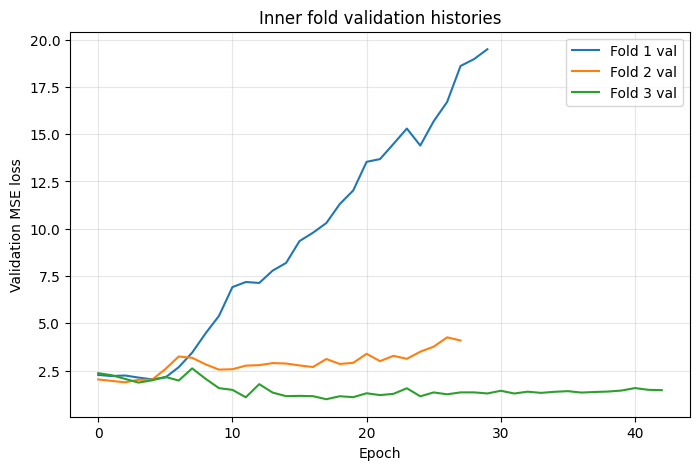

In [50]:
if split_output["mode"] == "holdout":
    plt.figure(figsize=(8, 5))
    plt.plot(result["history"]["train_loss"], label="Train loss")
    plt.plot(result["history"]["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(f"MLP training history ({SPLIT_METHOD})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    plt.figure(figsize=(8, 5))
    for i, history in enumerate(result["fold_histories"], start=1):
        plt.plot(history["val_loss"], label=f"Fold {i} val")
    plt.xlabel("Epoch")
    plt.ylabel("Validation MSE loss")
    plt.title("Inner fold validation histories")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

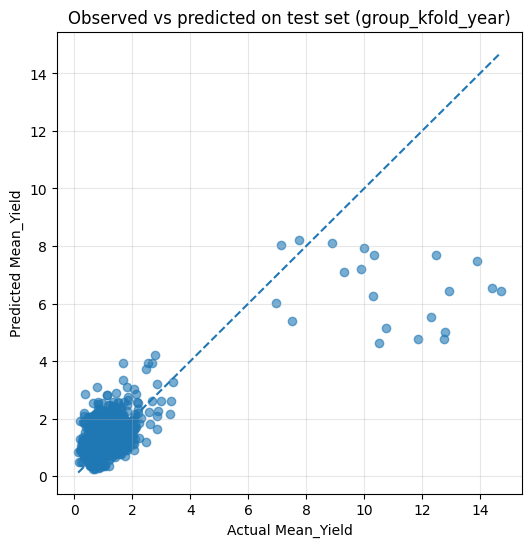

In [51]:
if split_output["mode"] == "holdout":
    y_true = result["outputs"]["test"]["y_true"]
    y_pred = result["outputs"]["test"]["y_pred"]
else:
    y_true = result["final_outputs"]["test"]["y_true"]
    y_pred = result["final_outputs"]["test"]["y_pred"]

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.6)
lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], linestyle="--")
plt.xlabel("Actual Mean_Yield")
plt.ylabel("Predicted Mean_Yield")
plt.title(f"Observed vs predicted on test set ({SPLIT_METHOD})")
plt.grid(True, alpha=0.3)
plt.show()

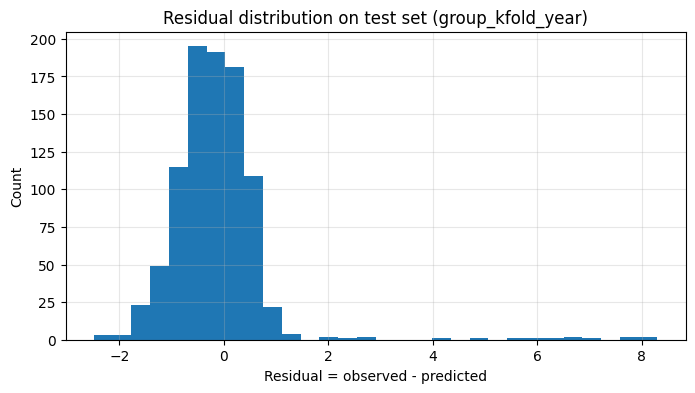

In [52]:
residuals = y_true - y_pred
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30)
plt.xlabel("Residual = observed - predicted")
plt.ylabel("Count")
plt.title(f"Residual distribution on test set ({SPLIT_METHOD})")
plt.grid(True, alpha=0.3)
plt.show()

## Notes

- This notebook always includes `Crop`.
- `Municipality` is excluded, matching the latitude/longitude approach used elsewhere in the project.
- For `group_kfold_year`, the fold table shows inner validation performance, while the final metrics table reports performance on the outer test years.
